In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data Cleaning and Processing

In [2]:
def get_data(file_path, opening_balance):
  excel_file_path = file_path
  df = pd.read_excel(excel_file_path)

  # Drop unnecessary columns (Vch No and Vch Type)
  df = df.drop(columns=['Vch No.', 'Vch Type'], errors='ignore')

  # Ensure 'Date' is in datetime format and fill NaN values in Debit and Credit
  df['Date'] = pd.to_datetime(df['Date'])
  df['Debit'] = df['Debit'].fillna(0)
  df['Credit'] = df['Credit'].fillna(0)

  # Calculate balance: Balance = opening_balance + Debit - Credit
  df['Calculated Balance'] = opening_balance + (df['Debit'] - df['Credit']).cumsum()

  # Extract month for grouping
  df['Month'] = df['Date'].dt.to_period('M')

  # Call the plotting functions
  plot_monthly_credit_debit(df)
  plot_cumulative_balance(df)
  plot_total_balance_bubble(df)
  # plot_total_balance_bubble_two_months(df)
  # plot_credit_balance_ratio(df)
  return df

# Visualization Functions

In [3]:
# 1. Monthly Credit vs. Debit as a Grouped Bar Chart
def plot_monthly_credit_debit(df):
    monthly_summary = df.groupby('Month').agg({'Debit': 'sum', 'Credit': 'sum'}).reset_index()
    plt.figure(figsize=(10, 4))
    bar_width = 0.35
    x = range(len(monthly_summary))
    plt.bar(x, monthly_summary['Debit'], width=bar_width, color='skyblue', label='Debit')
    plt.bar([p + bar_width for p in x], monthly_summary['Credit'], width=bar_width, color='palegreen', label='Credit')
    plt.xticks([p + bar_width / 2 for p in x], monthly_summary['Month'].astype(str), rotation=45)
    plt.title('Monthly Credit vs Debit')
    plt.ylabel('Amount in Rs')
    plt.xlabel('Month')
    plt.legend()
    plt.grid(axis='y')
    plt.show()

In [4]:
# 2. Cumulative Balance Over Time
def plot_cumulative_balance(df):
    plt.figure(figsize=(10, 4))
    plt.plot(df['Date'], df['Calculated Balance'], marker='o', color='b')
    plt.xticks(rotation=45)
    plt.title('Cumulative Balance Over Time')
    plt.ylabel('Balance (Positive = Client Owes You) in Rs')
    plt.xlabel('Date')
    plt.grid(True)
    plt.show()

In [5]:
# 3. Total Balance at the End of Each Month as a Bubble Chart
def plot_total_balance_bubble(df):
    total_balance = df.groupby('Month')['Calculated Balance'].last().reset_index()
    plt.figure(figsize=(10, 4))
    # Normalize the size of the bubbles for better visualization
    bubble_size = total_balance['Calculated Balance'] / total_balance['Calculated Balance'].max() * 1000
    plt.scatter(total_balance['Month'].astype(str), total_balance['Calculated Balance'], s=bubble_size, color='orange', alpha=0.5, edgecolors='w', linewidth=2)
    plt.xticks(rotation=45)
    plt.title('Total Balance at the End of Each Month')
    plt.ylabel('Total Balance in Rs')
    plt.xlabel('Month')
    plt.grid(True)
    plt.show()

# Elegance

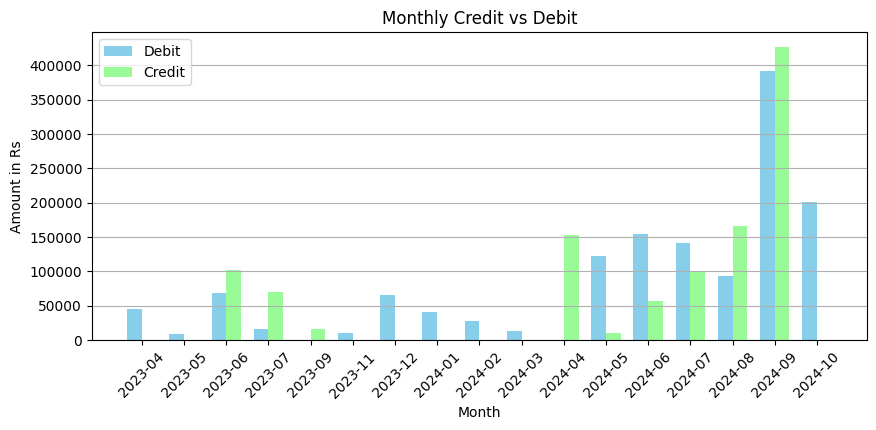

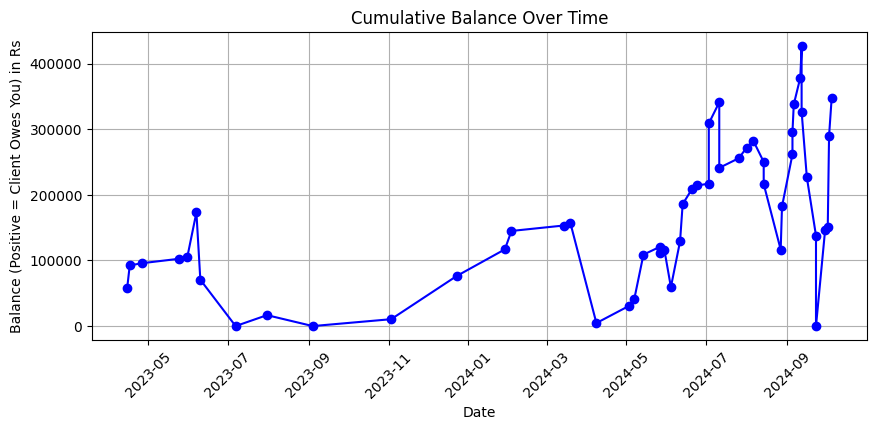

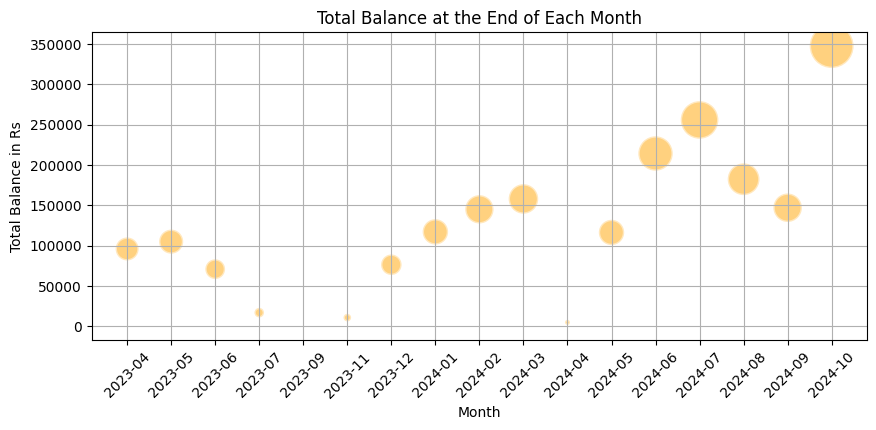

In [8]:
excel_file_path = 'Elegance.xlsx'
opening_balance = 49820
Elegance = get_data(excel_file_path, opening_balance)


# Ratnakar

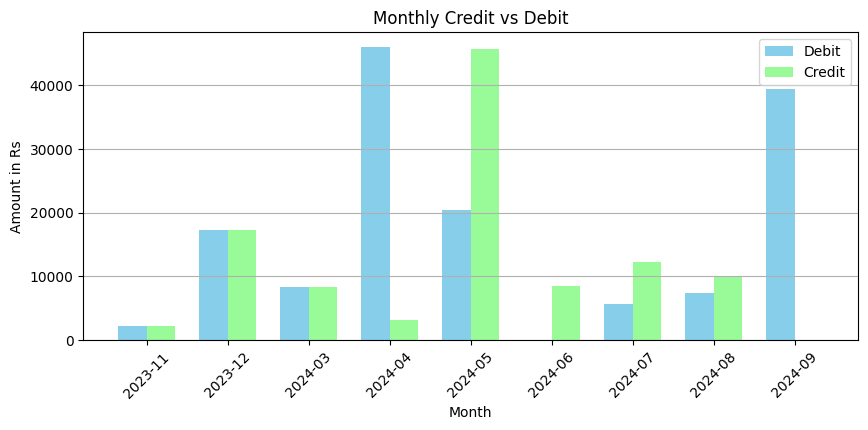

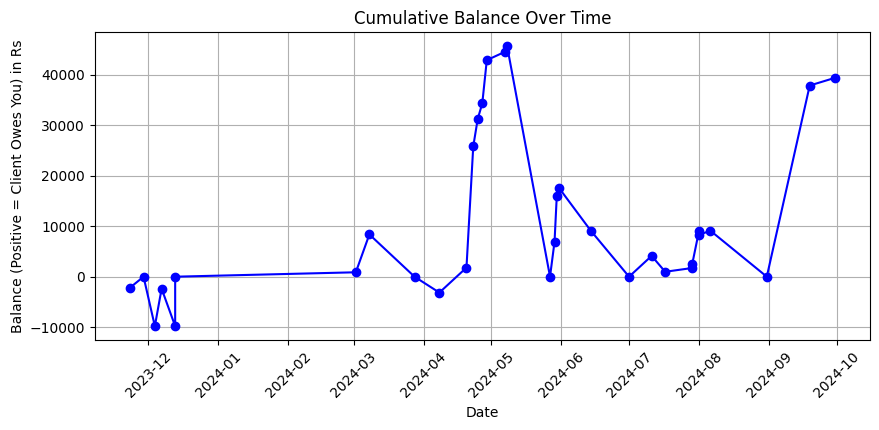

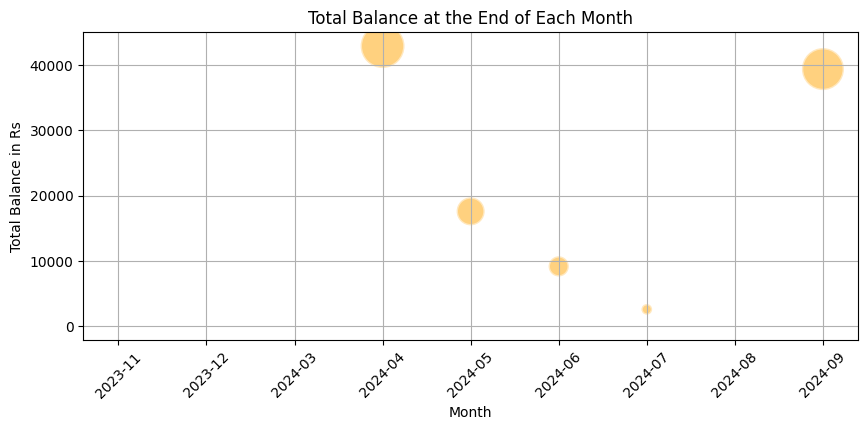

In [9]:
excel_file_path = 'Ratnakar.xlsx'
opening_balance = 0
Ratnakar = get_data(excel_file_path,opening_balance)


# Jesal

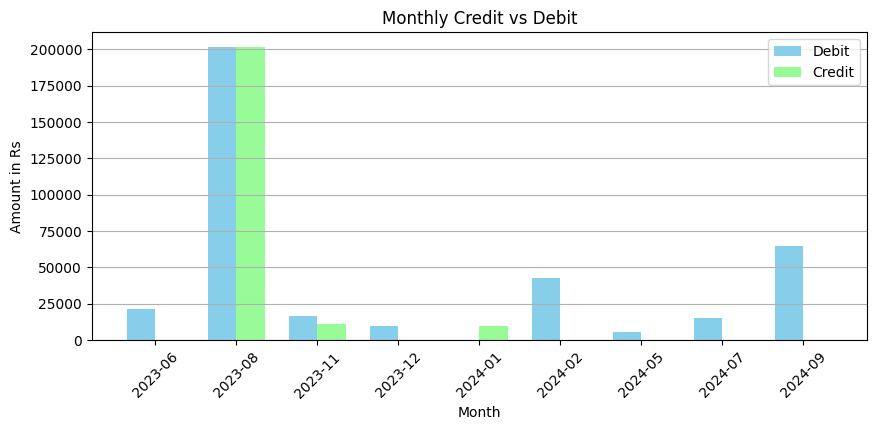

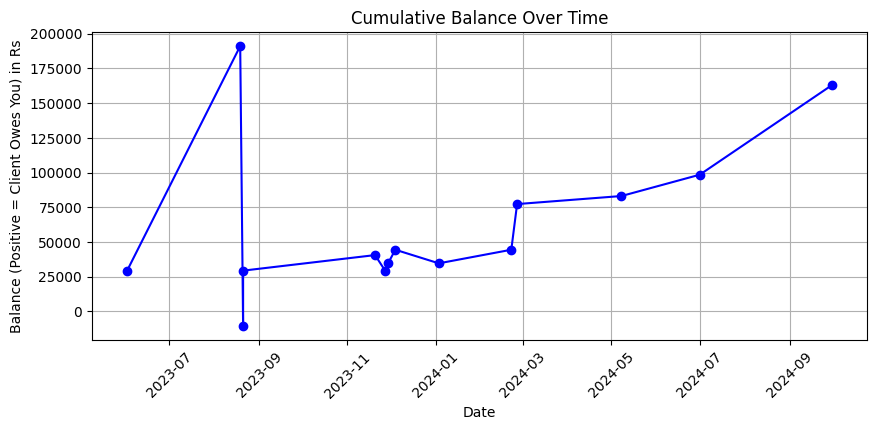

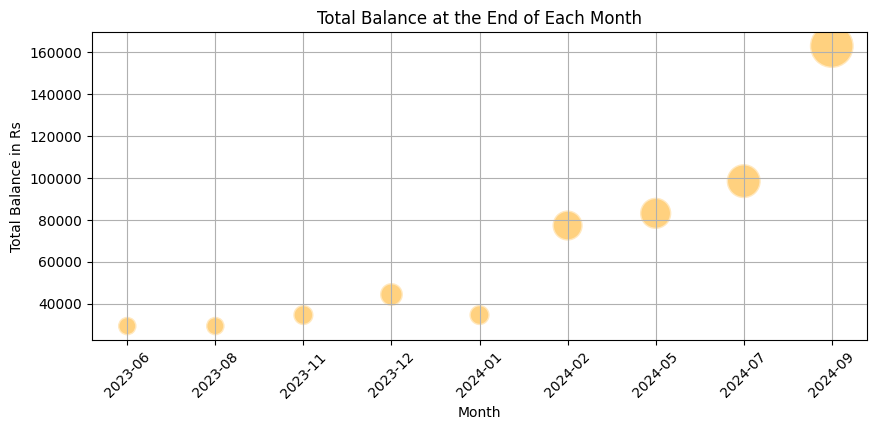

In [10]:
excel_file_path = 'Jesal.xlsx'
opening_balance = 8105
Jesal = get_data(excel_file_path, opening_balance)


# KumarAgro

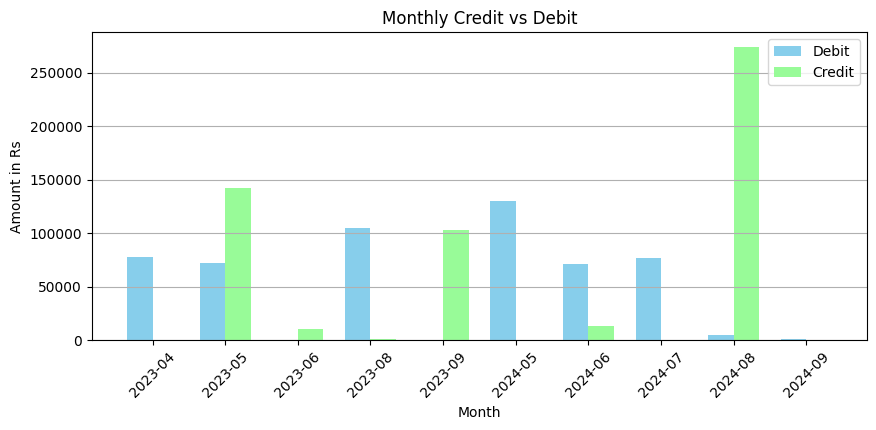

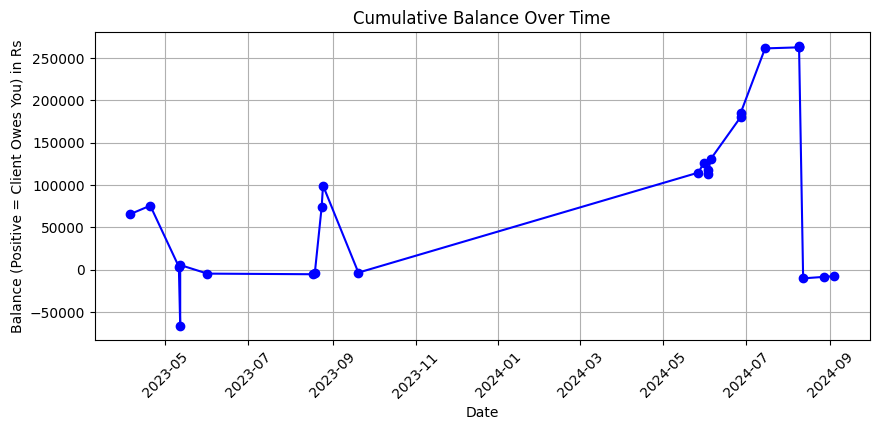

/usr/local/lib/python3.10/dist-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


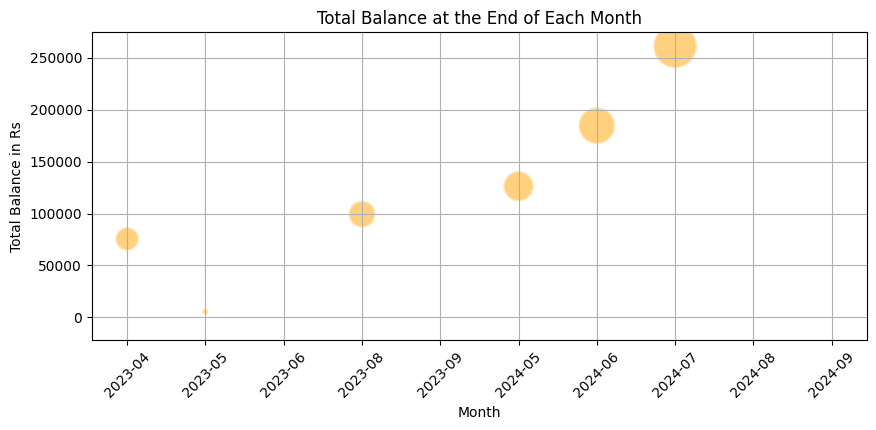

In [11]:
excel_file_path = 'KumarAgro.xlsx'
opening_balance = -1684
KumarAgro = get_data(excel_file_path, opening_balance)


# ShantiSales

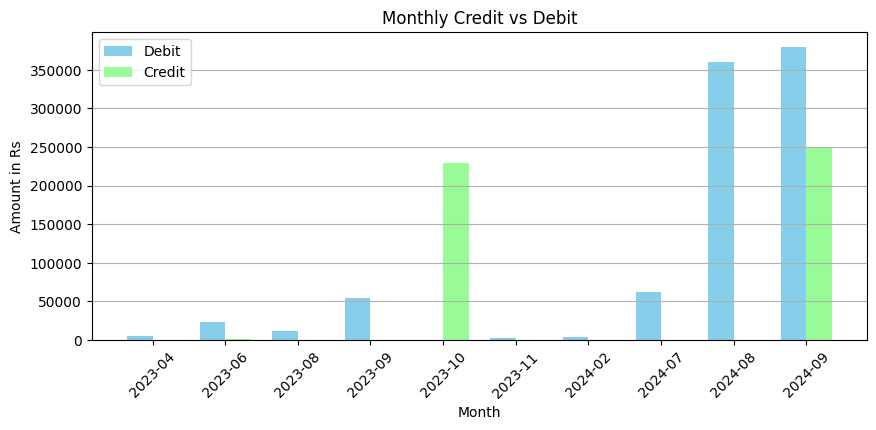

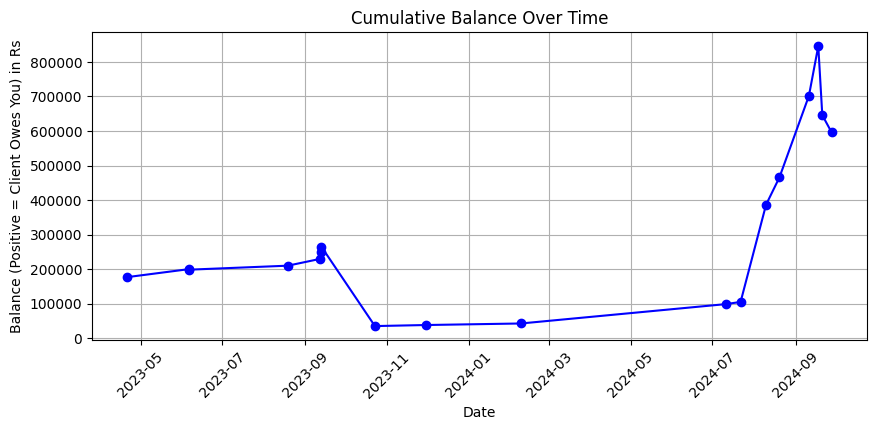

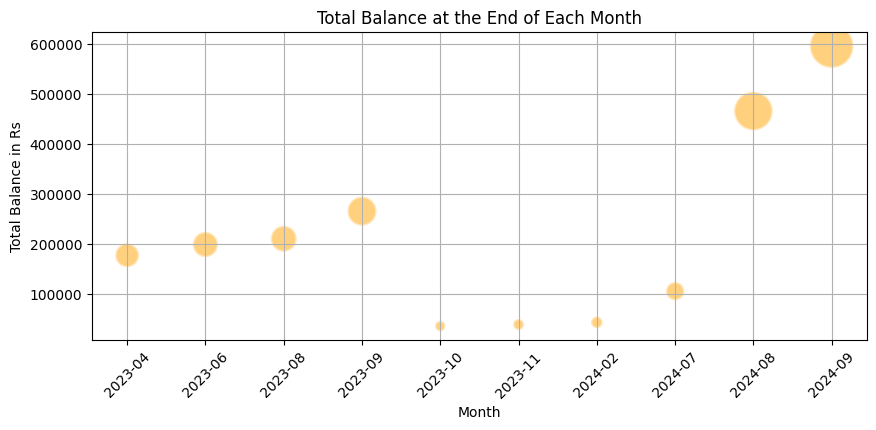

In [12]:
excel_file_path = 'ShantiSales.xlsx'
opening_balance = 172176
ShantiSales = get_data(excel_file_path, opening_balance)

# Chetan

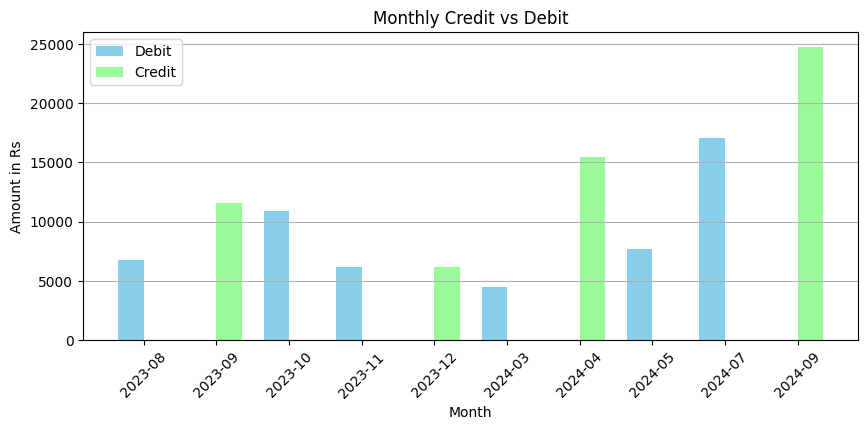

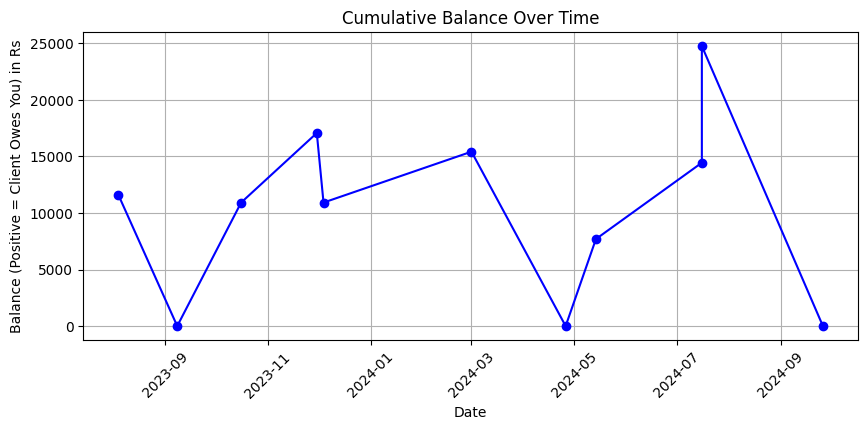

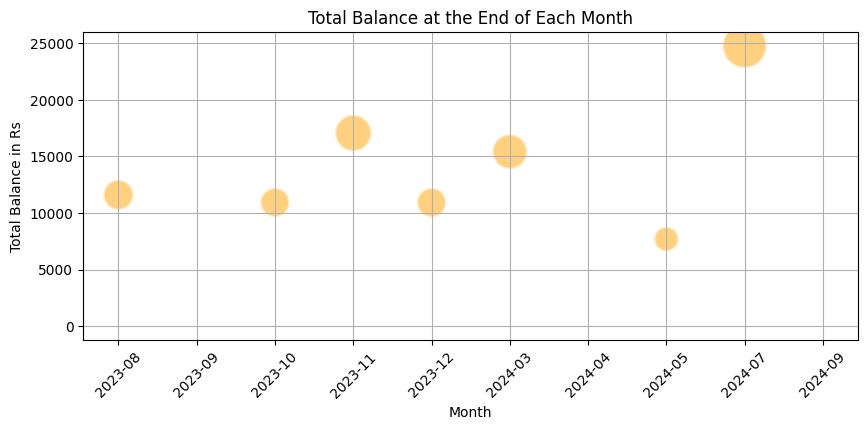

In [13]:
excel_file_path = 'Chetan.xlsx'
opening_balance = 4851
Chetan = get_data(excel_file_path, opening_balance)

# M.S. Corp

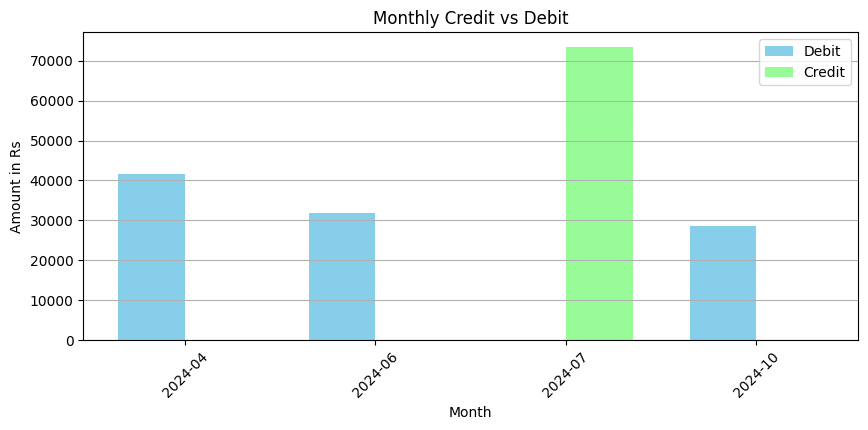

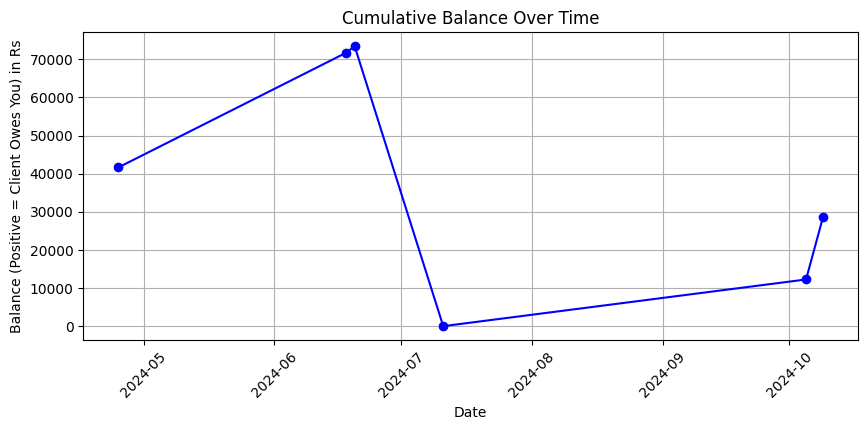

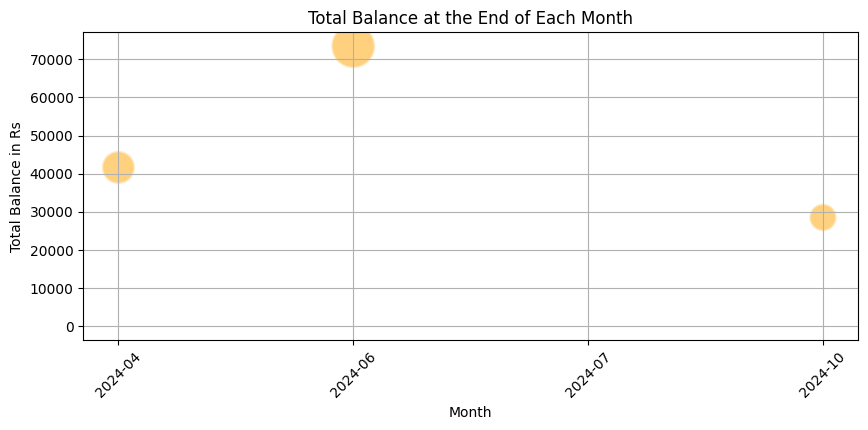

In [14]:
excel_file_path = 'MSCorp.xlsx'
opening_balance = 0
MSCorp = get_data(excel_file_path, opening_balance)

# Mehta

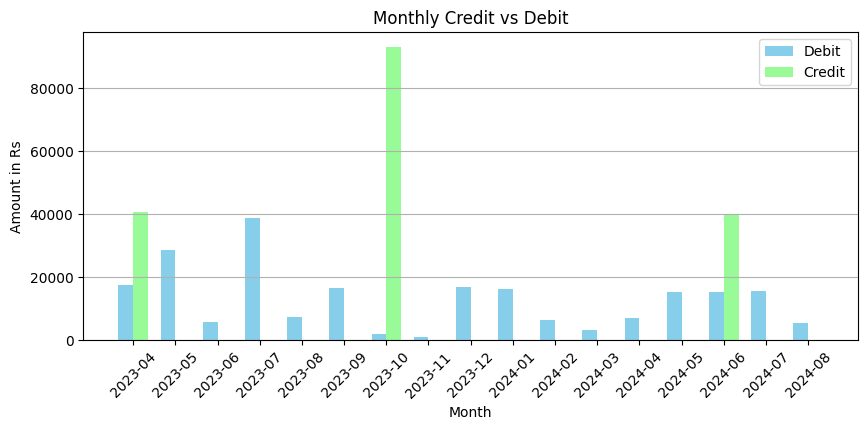

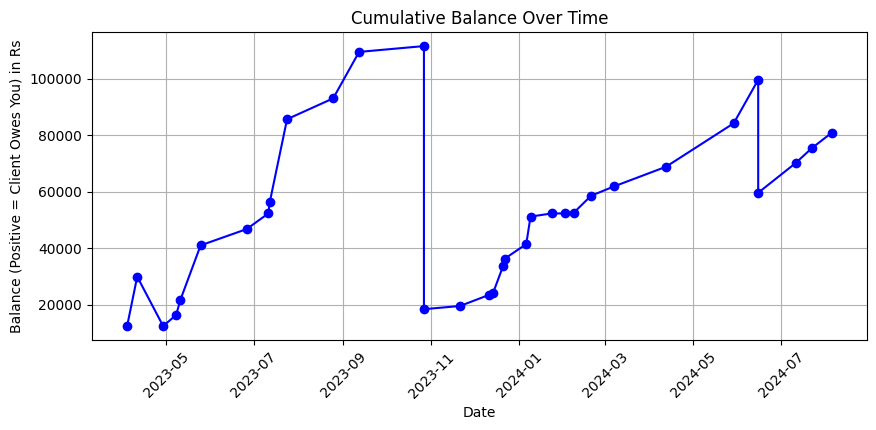

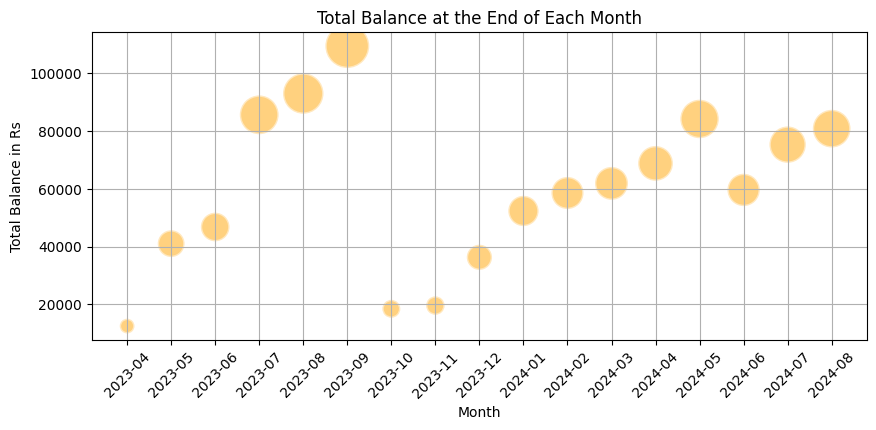

In [15]:
excel_file_path = 'Mehta.xlsx'
opening_balance = 35719
Mehta = get_data(excel_file_path, opening_balance)

# Nitin

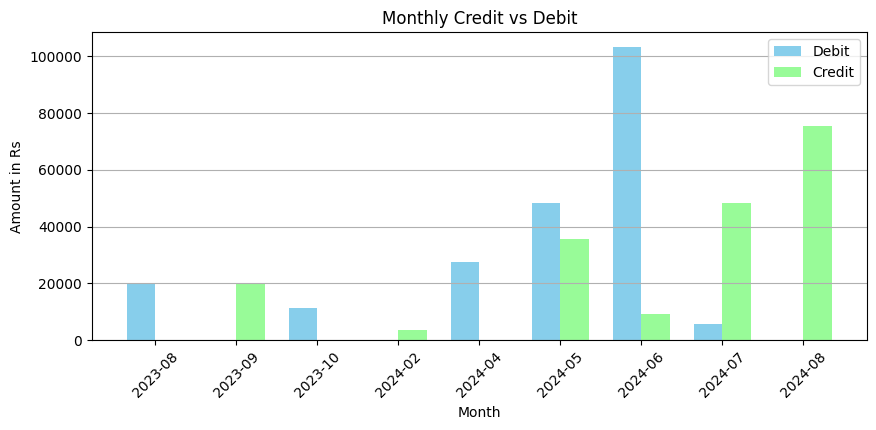

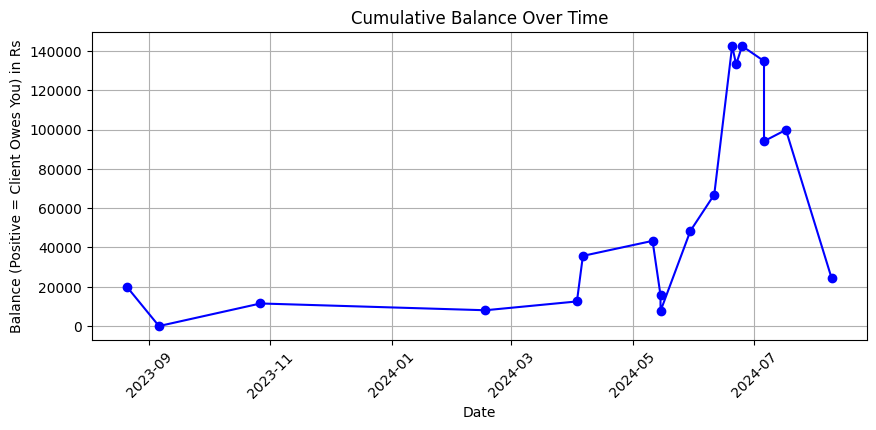

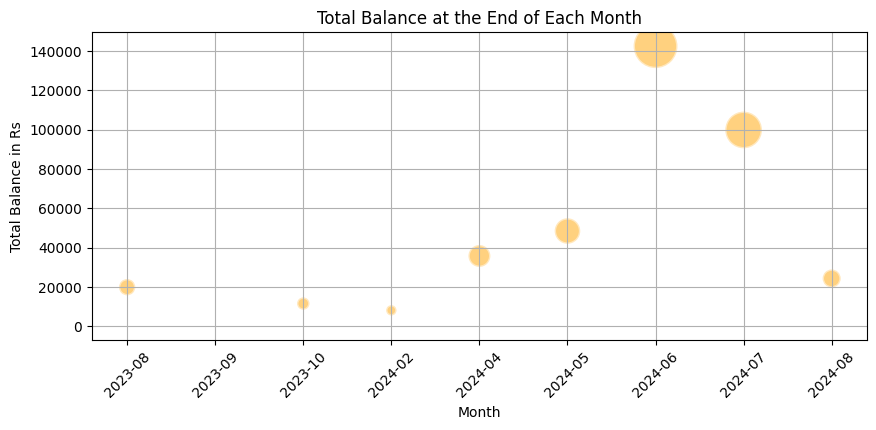

In [16]:
excel_file_path = 'Nitin.xlsx'
opening_balance = 0
Nitin = get_data(excel_file_path, opening_balance)

# Nakoda

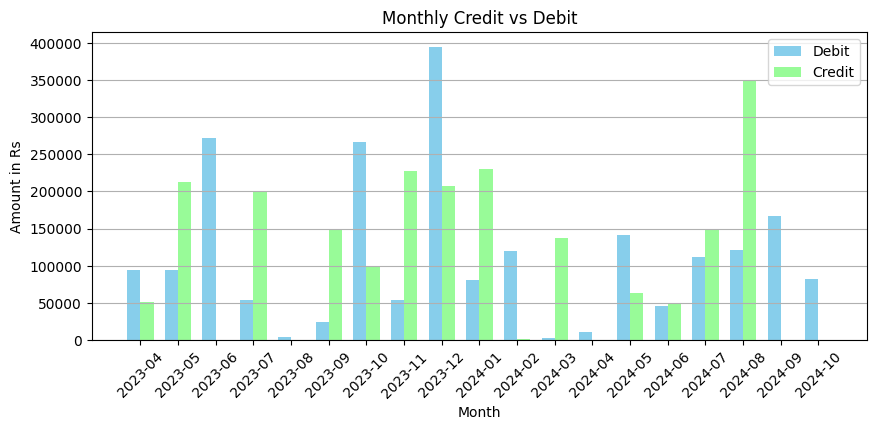

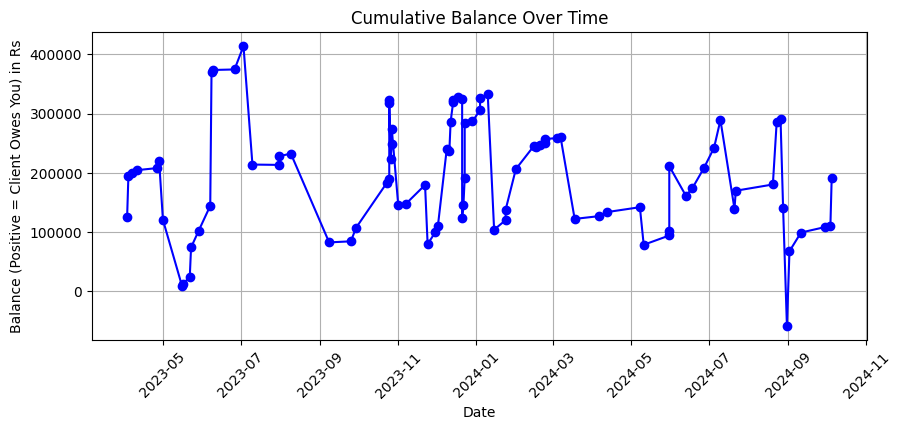

/usr/local/lib/python3.10/dist-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


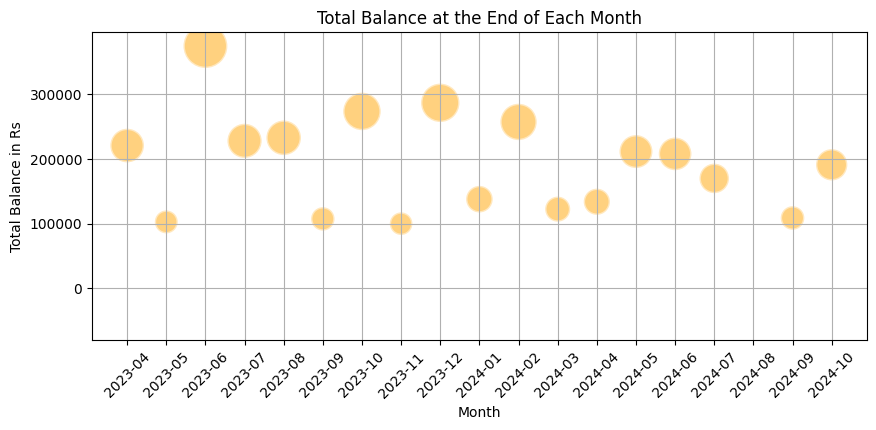

In [17]:
excel_file_path = 'Nakoda.xlsx'
opening_balance = 177028
Nakoda = get_data(excel_file_path, opening_balance)

# **All Together**

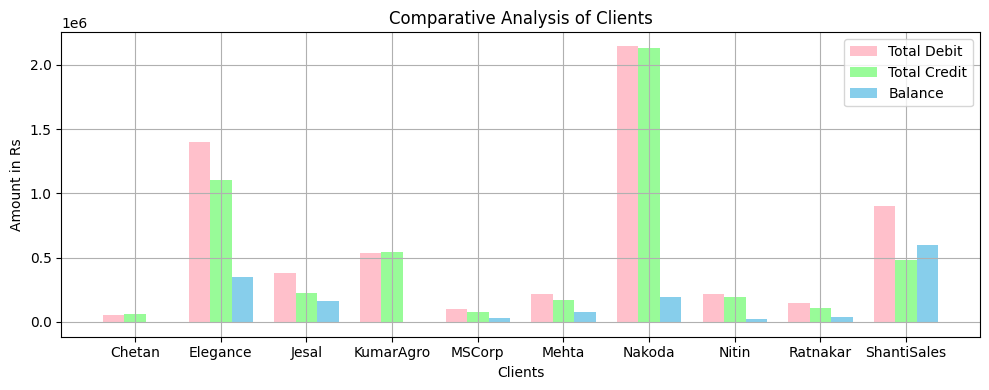

In [18]:
# Concatenate into one DataFrame
all_clients_df = pd.concat([Elegance, Ratnakar, Jesal, Chetan, KumarAgro, MSCorp, Mehta, Nitin, ShantiSales, Nakoda], keys=['Elegance', 'Ratnakar', 'Jesal', 'Chetan', 'KumarAgro', 'MSCorp', 'Mehta', 'Nitin', 'ShantiSales', 'Nakoda'])

# Reset the index to flatten the DataFrame
all_clients_df.reset_index(level=0, inplace=True)
all_clients_df.rename(columns={'level_0': 'Client'}, inplace=True)

# Calculate necessary metrics for each client
summary = all_clients_df.groupby('Client').agg({
    'Debit': 'sum',
    'Credit': 'sum',
    'Calculated Balance': 'last'  # current balance
}).reset_index()

plt.figure(figsize=(10, 4))
bar_width = 0.25
x = range(len(summary))

plt.bar(x, summary['Debit'], width=bar_width, label='Total Debit', color='pink', align='center')
plt.bar([p + bar_width for p in x], summary['Credit'], width=bar_width, label='Total Credit', color='palegreen', align='center')
plt.bar([p + bar_width * 2 for p in x], summary['Calculated Balance'], width=bar_width, label='Balance', color='skyblue', align='center')

plt.title('Comparative Analysis of Clients')
plt.xticks([p + bar_width for p in x], summary['Client'])
plt.ylabel('Amount in Rs')
plt.xlabel('Clients')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **Suggested Solution**

The cummulative balance of a month should be paid in full in the
subsequent month as and when feasible to the client.
If the dues are not paid within the first month then a 4% interest will be charged on the remaining balance amount and similarly a 5% interest will be charged for the second subsequent month.
If the balance is not completely cleared within 3 months further orders will not be accepted until all the dues are paid.